Step 1 — Import Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


Step 2 — Load and Preprocess the MNIST Dataset

In [ ]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images from 28x28 to 784 pixels
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Data preprocessing completed successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape: (10000, 784)
Data preprocessing completed successfully!


Step 3 — Display Sample MNIST Images

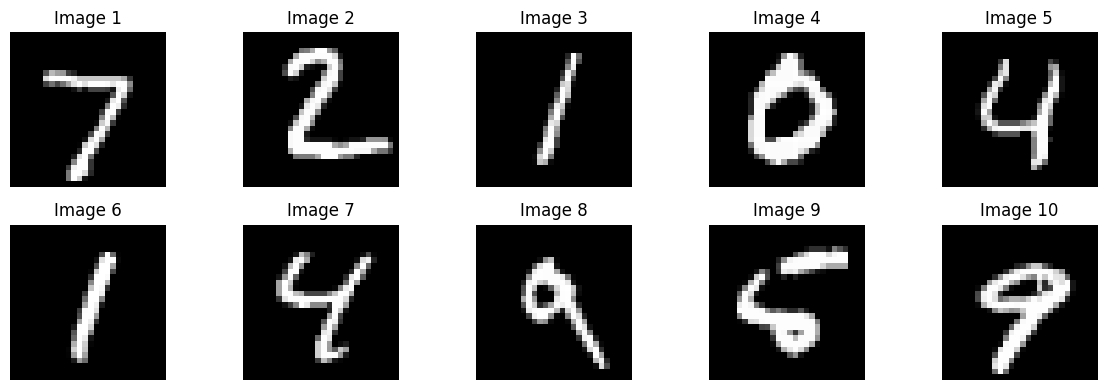

In [ ]:
# Reshape a few test images back to 28x28 for visualization
sample_images = x_test[:10].reshape(-1, 28, 28)

# Display sample images
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()

Step 4 — Build the Autoencoder Architecture

In [ ]:
# Define the input layer
input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(64, activation="relu")(encoded)
latent = layers.Dense(32, activation="relu", name="latent_space")(encoded)

# Decoder
decoded = layers.Dense(64, activation="relu")(latent)
decoded = layers.Dense(128, activation="relu")(decoded)
output_img = layers.Dense(784, activation="sigmoid")(decoded)

# Create Autoencoder model
autoencoder = Model(input_img, output_img)

# Compile the model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Display model architecture
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Step 5 — Train the Autoencoder

In [ ]:
# Train the Autoencoder
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

print("Autoencoder training completed successfully!")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.2492 - val_loss: 0.1665
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1501 - val_loss: 0.1345
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1286 - val_loss: 0.1209
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1191 - val_loss: 0.1150
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1133 - val_loss: 0.1094
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1090 - val_loss: 0.1063
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1061 - val_loss: 0.1041
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1040 - val_loss: 0.1019
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1021 - val_loss: 0.1000
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1005 - val_loss: 0.0988
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0990 - val_loss: 0.0976
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
x_train, x_train

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

Step 6 — Plot Autoencoder Training Loss

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Step 7 — Generate Reconstructed Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


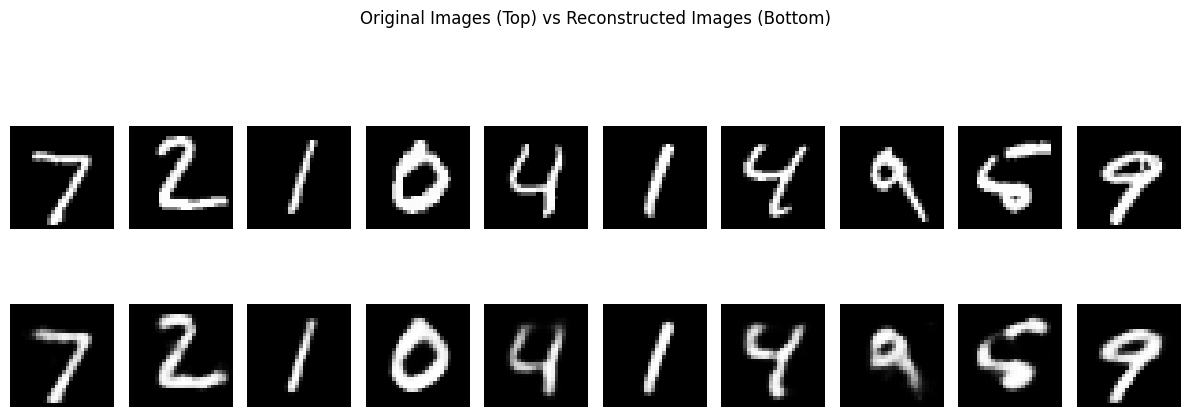

In [ ]:
# Generate reconstructed images
reconstructed_images = autoencoder.predict(x_test[:10])

# Reshape images back to 28x28
original_images = x_test[:10].reshape(-1, 28, 28)
reconstructed_images = reconstructed_images.reshape(-1, 28, 28)

# Display original and reconstructed images
plt.figure(figsize=(12, 5))

for i in range(10):
    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(original_images[i], cmap="gray")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images (Top) vs Reconstructed Images (Bottom)")
plt.tight_layout()
plt.show()

Step 8 — Extract and Visualize the Latent Space

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Latent representation shape: (2000, 32)


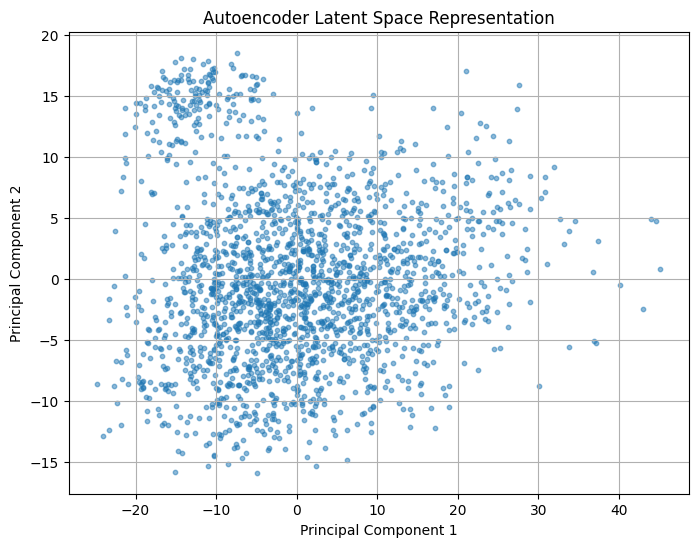

In [ ]:
from sklearn.decomposition import PCA

# Create an encoder model to extract latent representations
encoder = Model(input_img, latent)

# Generate latent representations for 2000 test images
latent_features = encoder.predict(x_test[:2000])

print("Latent representation shape:", latent_features.shape)

# Reduce 32 dimensions to 2 dimensions using PCA
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_features)

# Plot the latent space
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Autoencoder Latent Space Representation")
plt.grid(True)

plt.show()

Step 9 — Build the Variational Autoencoder (VAE)

In [ ]:
# VAE parameters
input_dim = 784
latent_dim = 2

# Sampling function
def sampling(args):
    z_mean, z_log_var = args

    epsilon = tf.keras.backend.random_normal(
        shape=(tf.shape(z_mean)[0], latent_dim)
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# Encoder
vae_input = layers.Input(shape=(input_dim,))

x = layers.Dense(128, activation="relu")(vae_input)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder_vae = Model(
    vae_input,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

encoder_vae.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    100,480 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,996 (425.77 KB)

 Trainable params: 108,996 (425.77 KB)

 Non-trainable params: 0 (0.00 B)

Step 10 — Build the VAE Decoder

In [ ]:
# Decoder network

latent_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(64, activation="relu")(latent_input)
x = layers.Dense(128, activation="relu")(x)

decoder_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder_vae = Model(
    latent_input,
    decoder_output,
    name="VAE_Decoder"
)

decoder_vae.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,648 (428.31 KB)

 Trainable params: 109,648 (428.31 KB)

 Non-trainable params: 0 (0.00 B)

Step 11 — Connect Encoder and Decoder to Create VAE Model

In [ ]:
# VAE parameters (latent_dim and input_dim are already defined in previous cells)
input_dim = 784
latent_dim = 2

# Define the VAE class by subclassing tf.keras.Model
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, input_dim):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim

    def call(self, inputs):
        # During inference, we just want the reconstruction
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def _compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        # Reconstruction loss (binary_crossentropy is calculated per-pixel)
        epsilon = tf.keras.backend.epsilon()
        reconstruction_loss_per_pixel = - (x * tf.keras.ops.log(reconstruction + epsilon) +
                                         (1 - x) * tf.keras.ops.log(1 - reconstruction + epsilon))
        # Shape is (batch_size, input_dim)
        reconstruction_loss_per_sample = tf.keras.ops.sum(reconstruction_loss_per_pixel, axis=-1)

        # KL divergence loss (calculated per-sample)
        kl_loss_per_sample = -0.5 * tf.keras.ops.sum(
            1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var),
            axis=-1
        ) # Shape (batch_size,)

        # Total loss is the mean over the batch
        total_loss = tf.keras.ops.mean(reconstruction_loss_per_sample + kl_loss_per_sample)
        return total_loss, reconstruction_loss_per_sample, kl_loss_per_sample

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss_per_sample, kl_loss_per_sample = self._compute_losses(x)

        # Apply gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": tf.keras.ops.mean(reconstruction_loss_per_sample),
            "kl_loss": tf.keras.ops.mean(kl_loss_per_sample)
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        total_loss, reconstruction_loss_per_sample, kl_loss_per_sample = self._compute_losses(x)

        return {
            "loss": total_loss,
            "reconstruction_loss": tf.keras.ops.mean(reconstruction_loss_per_sample),
            "kl_loss": tf.keras.ops.mean(kl_loss_per_sample)
        }

# Instantiate the VAE model using the previously defined encoder and decoder
vae = VAE(encoder_vae, decoder_vae, input_dim)

# Compile the VAE model (no explicit loss function needed as it's handled in train_step/test_step)
vae.compile(optimizer="adam")

vae.summary()

Model: "vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ VAE_Encoder (Functional)        │ [(None, 2), (None, 2), │       108,996 │
│                                 │ (None, 2)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ VAE_Decoder (Functional)        │ (None, 784)            │       109,648 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,644 (854.08 KB)

 Trainable params: 218,644 (854.08 KB)

 Non-trainable params: 0 (0.00 B)

Step 12 — Train the Variational Autoencoder (VAE)

In [ ]:
# Train VAE model

vae_history = vae.fit(
    x_train,
    y=None, # Pass only x_train as input, as loss is computed in custom train_step
    epochs=20,
    batch_size=256,
    validation_data=x_test # Pass only x_test for validation
)

print("VAE training completed successfully!")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - kl_loss: 5.3873 - loss: 168.0283 - reconstruction_loss: 162.6411 - val_kl_loss: 5.5877 - val_loss: 161.4010 - val_reconstruction_loss: 155.8132
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - kl_loss: 5.5242 - loss: 142.7528 - reconstruction_loss: 137.2286 - val_kl_loss: 5.5231 - val_loss: 157.2683 - val_reconstruction_loss: 151.7452
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - kl_loss: 5.3625 - loss: 155.7121 - reconstruction_loss: 150.3495 - val_kl_loss: 5.6702 - val_loss: 153.8850 - val_reconstruction_loss: 148.2148
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - kl_loss: 5.9021 - loss: 143.3217 - reconstruction_loss: 137.4195 - val_kl_loss: 5.8390 - val_loss: 153.2544 - val_reconstruction_loss: 147.4154
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl_loss: 5.7313 - loss: 149.7759 - reconstruction_loss: 144.0446 - val_kl_loss: 5.7593 - val_loss: 151.8394 - val_reconstruction_loss: 146.0800
Epoc

Step 13 — Plot VAE Training Loss

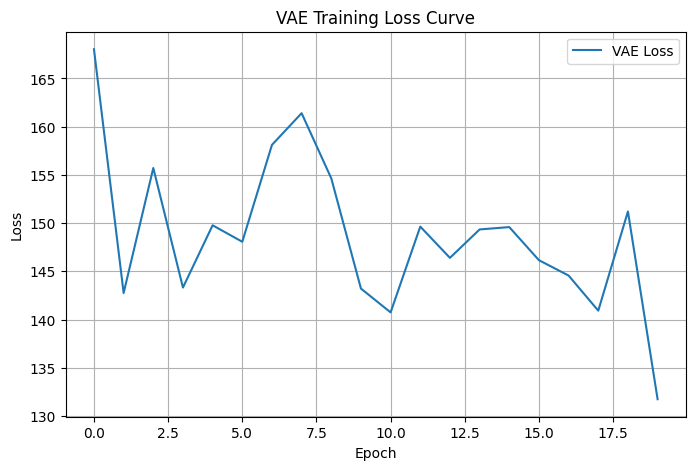

In [ ]:
# Plot VAE training loss

plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["loss"],
    label="VAE Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

Step 14 — Generate VAE Reconstructed Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


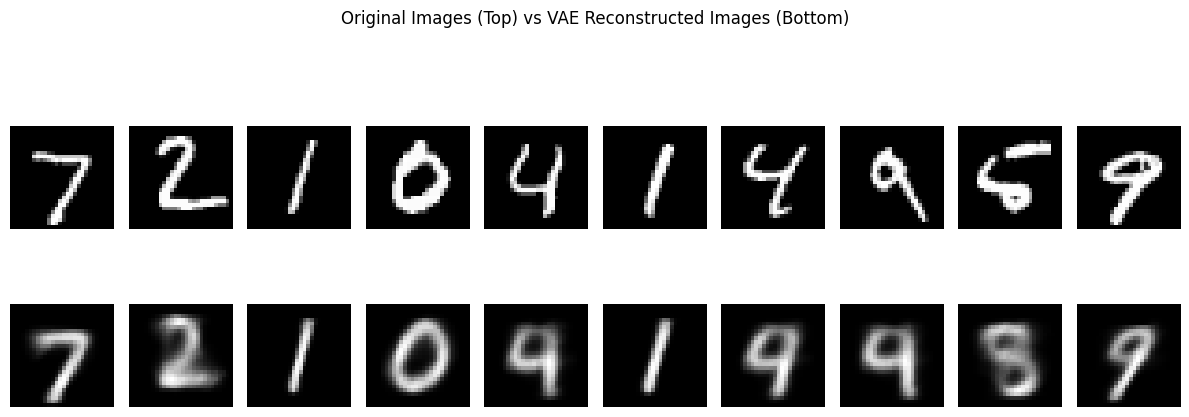

In [ ]:
# Get latent representation from encoder

z_mean, z_log_var, z = encoder_vae.predict(
    x_test[:10]
)

# Generate reconstructed images
vae_reconstructed = decoder_vae.predict(z)

# Reshape images back to 28x28
original_images = x_test[:10].reshape(-1, 28, 28)
vae_reconstructed = vae_reconstructed.reshape(-1, 28, 28)


# Display original and reconstructed images

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original images
    plt.subplot(2, 10, i + 1)
    plt.imshow(original_images[i], cmap="gray")
    plt.axis("off")

    # VAE reconstructed images
    plt.subplot(2, 10, i + 11)
    plt.imshow(vae_reconstructed[i], cmap="gray")
    plt.axis("off")


plt.suptitle("Original Images (Top) vs VAE Reconstructed Images (Bottom)")
plt.tight_layout()
plt.show()

Step 15 — Visualize VAE Latent Space

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


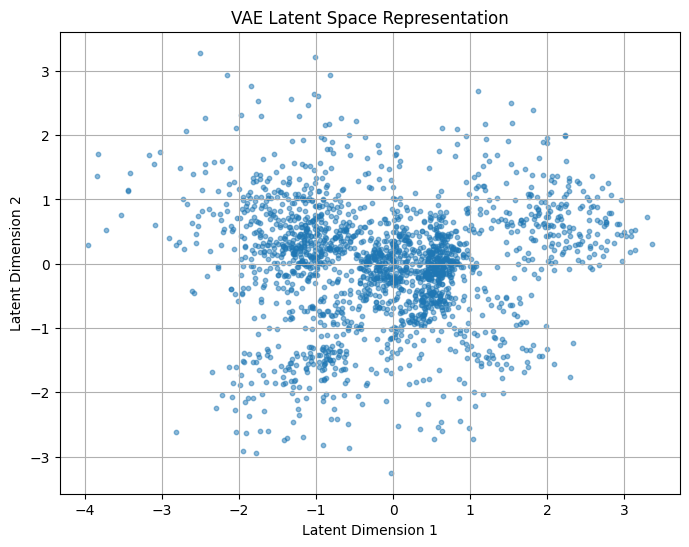

In [ ]:
# Extract latent space from VAE encoder

z_mean, z_log_var, z = encoder_vae.predict(
    x_test[:2000]
)

# Plot latent space

plt.figure(figsize=(8, 6))

plt.scatter(
    z[:, 0],
    z[:, 1],
    s=10,
    alpha=0.5
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space Representation")
plt.grid(True)

plt.show()

Step 16 — Compare Autoencoder and VAE Reconstruction Quality

In [ ]:
# Generate Autoencoder reconstructions

ae_reconstructed = autoencoder.predict(x_test[:10])


# Generate VAE reconstructions

z_mean, z_log_var, z = encoder_vae.predict(x_test[:10])

vae_reconstructed = decoder_vae.predict(z)


# Calculate Mean Squared Error (MSE)

ae_mse = np.mean(
    np.square(
        x_test[:10] - ae_reconstructed
    )
)

vae_mse = np.mean(
    np.square(
        x_test[:10] - vae_reconstructed
    )
)


print("Autoencoder Reconstruction MSE:", ae_mse)
print("VAE Reconstruction MSE:", vae_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Autoencoder Reconstruction MSE: 0.008859013
VAE Reconstruction MSE: 0.042723067


Step 17 — Calculate Compression Efficiency

In [ ]:
# Original and compressed dimensions

original_dimension = 784

autoencoder_dimension = 32

vae_dimension = 2


# Calculate compression ratio

ae_compression_ratio = (
    original_dimension / autoencoder_dimension
)

vae_compression_ratio = (
    original_dimension / vae_dimension
)


print(
    "Autoencoder Compression Ratio:",
    round(ae_compression_ratio, 2),
    "times"
)

print(
    "VAE Compression Ratio:",
    round(vae_compression_ratio, 2),
    "times"
)

Autoencoder Compression Ratio: 24.5 times
VAE Compression Ratio: 392.0 times


Step 18 — Display Final Comparison Table

In [ ]:
import pandas as pd

# Create comparison table

comparison = pd.DataFrame({
    "Model": [
        "Autoencoder",
        "Variational Autoencoder (VAE)"
    ],
    "Latent Dimension": [
        32,
        2
    ],
    "Compression Ratio": [
        "24.5x",
        "392x"
    ],
    "Representation Type": [
        "Deterministic",
        "Probabilistic"
    ],
    "Main Purpose": [
        "Image reconstruction and compression",
        "Representation learning and image generation"
    ]
})


comparison

,Model,Latent Dimension,Compression Ratio,Representation Type,Main Purpose
0,Autoencoder,32,24.5x,Deterministic,Image reconstruction and compression
1,Variational Autoencoder (VAE),2,392x,Probabilistic,Representation learning and image generation


Step 19 — Generate Final Observations and Conclusion

## Observations

1. The Autoencoder successfully learned compact feature representations of MNIST images by reducing the original 784-dimensional input into a 32-dimensional latent space.

2. The reconstructed images generated by the Autoencoder preserved the major patterns and structures of handwritten digits.

3. The Variational Autoencoder learned a probabilistic latent representation using mean and variance, which resulted in a smoother and more organized latent space.

4. The latent space visualization showed that similar image features were grouped together, demonstrating effective representation learning.

5. Both Autoencoder and VAE achieved image compression, but they differed in their objectives. Autoencoder focused on reconstruction quality, while VAE focused on learning a meaningful latent distribution.

## Conclusion

In this task, Autoencoder and Variational Autoencoder models were implemented for representation learning and image compression using the MNIST dataset. The Autoencoder effectively reconstructed images using compressed features, while the VAE learned a structured latent space suitable for generating and analyzing image representations. The results demonstrate the importance of deep learning-based representation learning techniques for image compression and feature extraction.